# Implementation of Transfer Learning Using Pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0 for Image Classification and Performance Comparison

**Dataset:** CIFAR-10
**Framework:** TensorFlow / Keras
**Environment:** Jupyter Notebook / JupyterLab



In [4]:
#  Import Libraries
import sys
import os
import time
import json
import gc
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    accuracy_score,
)

sns.set_style("whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
# Environment / GPU detection -- prints the TRUTH about what TensorFlow can see.
print("Python version     :", sys.version)
print("Python executable  :", sys.executable)
print("TensorFlow version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected      :", gpus)
print("All physical devices:", tf.config.list_physical_devices())

if gpus:
    # Enable memory growth so TensorFlow does not grab all VRAM at once.
    # This is important for a 6 GB laptop GPU (RTX 4050) shared with the OS/display.
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            # Memory growth must be set before GPUs are initialized; safe to ignore if already set.
            print("Note:", e)
    USE_GPU = True
    print("\n[OK] GPU detected. Memory growth enabled. Training will use the GPU.")
else:
    USE_GPU = False
    print("\n[WARNING] No GPU detected by TensorFlow. Training will run on CPU and will be SLOWER.")
    print("See the 'GPU Troubleshooting' section at the end of this notebook if you expected a GPU here.")


Python version     : 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Python executable  : C:\Users\selot\anaconda3\python.exe
TensorFlow version : 2.21.0
GPUs detected      : []
All physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

[WARNING] No GPU detected by TensorFlow. Training will run on CPU and will be SLOWER.
See the 'GPU Troubleshooting' section at the end of this notebook if you expected a GPU here.


In [6]:
# Only enable mixed precision if a GPU was actually detected above.
if USE_GPU:
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy set to 'mixed_float16' (GPU detected).")
else:
    mixed_precision.set_global_policy("float32")
    print("Mixed precision left at 'float32' (no GPU detected).")

print("Current policy:", mixed_precision.global_policy())


Mixed precision left at 'float32' (no GPU detected).
Current policy: <DTypePolicy "float32">


## Reproducibility and Configuration

All key settings live in ONE cell below so you can easily tune them:

- Start with the small `TRAIN_SAMPLES` / `TEST_SAMPLES` subset and `EPOCHS = 5` to smoke-test the whole notebook quickly.
- Once everything runs without errors, increase `TRAIN_SAMPLES` to 50000, `TEST_SAMPLES` to 10000, and raise `EPOCHS` for a full run.
- If you hit GPU out-of-memory errors, lower `BATCH_SIZE` to 8.

The final results table will always report exactly how many samples and epochs were actually used — results are never presented as "full CIFAR-10" if a subset was used.


In [7]:

SEED = 42

# --- Dataset subset size (start small, increase once verified) ---
TRAIN_SAMPLES = 10000   # set to 50000 for the FULL CIFAR-10 training set
TEST_SAMPLES  = 2000    # set to 10000 for the FULL CIFAR-10 test set

# --- Training hyperparameters ---
EPOCHS = 5
BATCH_SIZE = 16 if USE_GPU else 8   # conservative default for a 6 GB laptop GPU; lower to 8 if OOM
LEARNING_RATE = 1e-4

# --- Image sizes per architecture ---
IMG_SIZE_ALEXNET = (64, 64)     # AlexNet is trained from scratch here, so a smaller size saves time/memory
IMG_SIZE_PRETRAINED = (224, 224)  # required input size for VGG16 / ResNet50 / EfficientNetB0

NUM_CLASSES = 10
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Set seeds for reproducibility ---
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration set.")
print(f"TRAIN_SAMPLES={TRAIN_SAMPLES}, TEST_SAMPLES={TEST_SAMPLES}, EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}")


Configuration set.
TRAIN_SAMPLES=10000, TEST_SAMPLES=2000, EPOCHS=5, BATCH_SIZE=8


##  Load CIFAR-10

`tf.keras.datasets.cifar10.load_data()` downloads (once, cached locally) and loads all 50,000 training + 10,000 test 32x32x3 images as NumPy arrays. This step alone is fine memory-wise (CIFAR-10 raw is only ~170 MB) — the danger the assignment warns about is resizing **all** of it to 224x224 into RAM, which we avoid by resizing lazily inside the `tf.data` pipeline instead.


In [17]:
# (x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# # Flatten label arrays from shape (N, 1) to (N,)
# y_train_full = y_train_full.flatten()
# y_test_full = y_test_full.flatten()

# print("Full training set :", x_train_full.shape, y_train_full.shape)
# print("Full test set      :", x_test_full.shape, y_test_full.shape)
# print("Pixel value range  :", x_train_full.min(), "-", x_train_full.max())
import os
import pickle
import numpy as np

# Path to the extracted CIFAR-10 dataset
CIFAR10_DIR = r"C:\Users\selot\Downloads\cifar-10-python\cifar-10-batches-py"

# Check that the dataset folder exists
if not os.path.exists(CIFAR10_DIR):
    raise FileNotFoundError(
        f"CIFAR-10 dataset not found at: {CIFAR10_DIR}\n"
        "Please check your data folder and notebook location."
    )




In [16]:
import os

CIFAR10_DIR = r"C:\Users\selot\Downloads\cifar-10-python"

print("Contents of folder:")
for item in os.listdir(CIFAR10_DIR):
    print(item)

Contents of folder:
cifar-10-batches-py


In [18]:
# Function to load one CIFAR-10 batch
def load_cifar10_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    # CIFAR-10 stores images as (N, 3072)
    # Convert to (N, 3, 32, 32)
    images = images.reshape(-1, 3, 32, 32)

    # Convert to (N, 32, 32, 3)
    images = images.transpose(0, 2, 3, 1)

    return images, labels


# -----------------------------
# Load training data
# -----------------------------

train_images = []
train_labels = []

for i in range(1, 6):
    file_path = os.path.join(
        CIFAR10_DIR,
        f"data_batch_{i}"
    )

    images, labels = load_cifar10_batch(file_path)

    train_images.append(images)
    train_labels.append(labels)


# Combine all five training batches
x_train_full = np.concatenate(train_images, axis=0)
y_train_full = np.concatenate(train_labels, axis=0)


# -----------------------------
# Load test data
# -----------------------------

test_file = os.path.join(
    CIFAR10_DIR,
    "test_batch"
)

x_test_full, y_test_full = load_cifar10_batch(test_file)


# -----------------------------
# Verify dataset
# -----------------------------

print("Full training set :", x_train_full.shape, y_train_full.shape)
print("Full test set      :", x_test_full.shape, y_test_full.shape)
print("Pixel value range  :", x_train_full.min(), "-", x_train_full.max())

Full training set : (50000, 32, 32, 3) (50000,)
Full test set      : (10000, 32, 32, 3) (10000,)
Pixel value range  : 0 - 255


##  Explore Dataset


        class  count
0    airplane   5000
1  automobile   5000
2        bird   5000
3         cat   5000
4        deer   5000
5         dog   5000
6        frog   5000
7       horse   5000
8        ship   5000
9       truck   5000


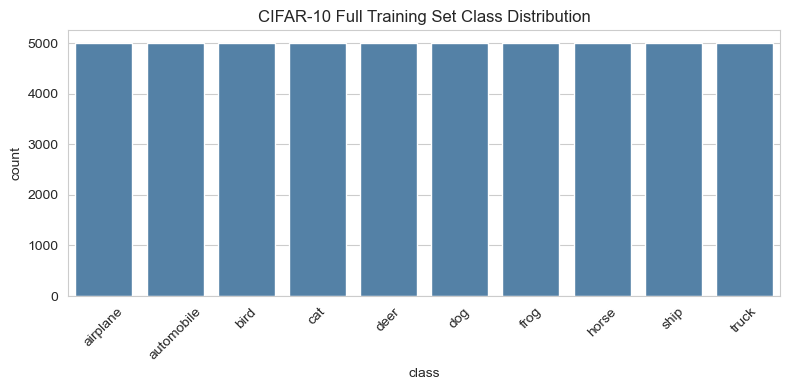

In [19]:
# Class distribution in the full training set
unique, counts = np.unique(y_train_full, return_counts=True)
dist_df = pd.DataFrame({"class": [CLASS_NAMES[i] for i in unique], "count": counts})
print(dist_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dist_df, x="class", y="count", color="steelblue")
plt.title("CIFAR-10 Full Training Set Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


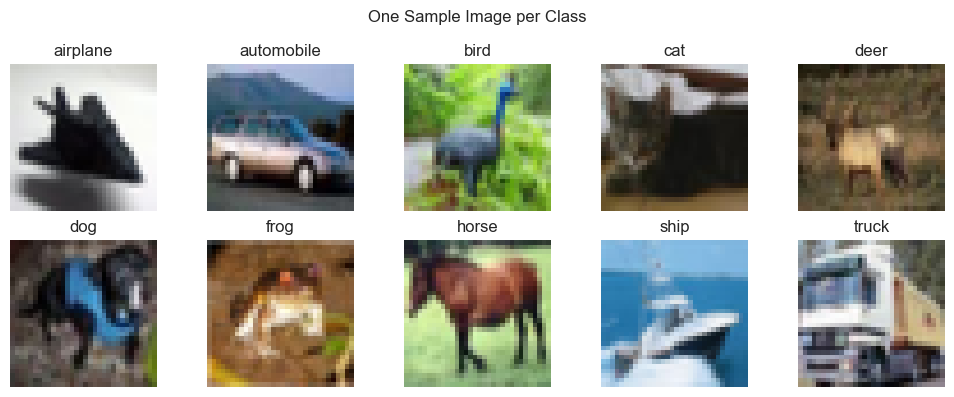

In [20]:
# Sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.where(y_train_full == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[idx])
    plt.title(CLASS_NAMES[i])
    plt.axis("off")
plt.suptitle("One Sample Image per Class")
plt.tight_layout()
plt.show()


## Create Configurable Subset

We take a shuffled subset of size `TRAIN_SAMPLES` / `TEST_SAMPLES` from the full dataset (see the configuration cell above). This lets you verify the whole pipeline quickly before committing to a full 50,000-image run.


In [21]:
rng = np.random.default_rng(SEED)

train_idx = rng.choice(len(x_train_full), size=min(TRAIN_SAMPLES, len(x_train_full)), replace=False)
test_idx = rng.choice(len(x_test_full), size=min(TEST_SAMPLES, len(x_test_full)), replace=False)

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]
x_test = x_test_full[test_idx]
y_test = y_test_full[test_idx]

# Further split a small validation set out of the training subset
val_fraction = 0.15
n_val = int(len(x_train) * val_fraction)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_train, y_train = x_train[n_val:], y_train[n_val:]

print(f"Using {len(x_train)} training, {len(x_val)} validation, {len(x_test)} test images "
      f"(out of {len(x_train_full)} / {len(x_test_full)} available).")


Using 8500 training, 1500 validation, 2000 test images (out of 50000 / 10000 available).


## Data Preprocessing

Each pretrained model expects its own specific pixel preprocessing (different normalization/scaling conventions). Using the wrong one silently hurts accuracy, so we use a dedicated preprocessing function per architecture:

- **AlexNet (custom):** simple `/255.0` scaling to `[0, 1]`.
- **VGG16:** `tf.keras.applications.vgg16.preprocess_input` (converts RGB->BGR and subtracts ImageNet channel means).
- **ResNet50:** `tf.keras.applications.resnet50.preprocess_input` (same convention as VGG16).
- **EfficientNetB0:** `tf.keras.applications.efficientnet.preprocess_input` (scales inputs internally; expects raw 0-255 float input).




In [22]:
def make_preprocess_fn(kind):
    """Return the correct preprocessing function for a given architecture name."""
    if kind == "alexnet":
        return lambda img: img / 255.0
    elif kind == "vgg16":
        return tf.keras.applications.vgg16.preprocess_input
    elif kind == "resnet50":
        return tf.keras.applications.resnet50.preprocess_input
    elif kind == "efficientnetb0":
        return tf.keras.applications.efficientnet.preprocess_input
    else:
        raise ValueError(f"Unknown model kind: {kind}")


def build_dataset(x, y, img_size, preprocess_fn, batch_size, shuffle=False, augment=False):
    """
    Build a memory-safe tf.data pipeline.
    - Keeps raw 32x32 uint8 images in memory (cheap).
    - Resizes + preprocesses lazily, batch by batch.
    - Uses shuffle/prefetch/batch as required.
    """
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(x), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _map_fn(image, label):
        image = tf.image.resize(image, img_size)          # resize lazily, per-batch
        image = tf.cast(image, tf.float32)
        if augment:
            image = tf.image.random_flip_left_right(image)
        image = preprocess_fn(image)                       # model-specific normalization
        label = tf.cast(label, tf.int32)
        return image, label

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print("Preprocessing / pipeline helper functions defined.")


Preprocessing / pipeline helper functions defined.


## Data Augmentation

Light augmentation (only a horizontal flip) is applied to the **training** set only, via the `augment=True` flag inside `build_dataset`. CIFAR-10 objects are not vertically symmetric in general (e.g. an upside-down truck is unrealistic), so we intentionally avoid vertical flips and heavy rotations that could hurt a low-resolution dataset like this.


In [23]:
# Quick smoke test of the pipeline with a small dummy preprocessing kind ("alexnet")
_test_ds = build_dataset(x_train[:64], y_train[:64], IMG_SIZE_ALEXNET,
                          make_preprocess_fn("alexnet"), batch_size=BATCH_SIZE,
                          shuffle=True, augment=True)
for batch_x, batch_y in _test_ds.take(1):
    print("Sample batch image shape:", batch_x.shape)
    print("Sample batch label shape:", batch_y.shape)
del _test_ds
print("Pipeline smoke test passed.")


Sample batch image shape: (8, 64, 64, 3)
Sample batch label shape: (8,)
Pipeline smoke test passed.


## Reusable Training and Evaluation Functions

These functions are shared by all four models so we don't repeat the same code four times.


In [24]:
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6),
        ModelCheckpoint(
            filepath=os.path.join(MODELS_DIR, f"{model_name}_best.keras"),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]


def train_model(model, train_ds, val_ds, model_name, epochs=EPOCHS):
    """Train a compiled model, timing the whole process. Returns (history, elapsed_seconds)."""
    callbacks = get_callbacks(model_name)
    print(f"--- Training {model_name} ---")
    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.time() - start_time
    print(f"--- Finished training {model_name} in {elapsed:.1f} seconds ---")
    return history, elapsed


def plot_history(history, model_name):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["accuracy"], label="Training Accuracy")
    axes[0].plot(hist["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{model_name} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist["loss"], label="Training Loss")
    axes[1].plot(hist["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{model_name} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_ds, y_true, model_name, elapsed_time, pretrained, fine_tuned):
    """Evaluate a trained model: loss/acc, precision/recall/F1, confusion matrix, report."""
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    total_params = model.count_params()
    trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)

    print(f"\n=== {model_name} Evaluation ===")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"Training time : {elapsed_time:.1f} s")
    print(f"Total params  : {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    result = {
        "Model": model_name,
        "Test Accuracy": round(float(test_acc), 4),
        "Precision": round(float(precision), 4),
        "Recall": round(float(recall), 4),
        "F1 Score": round(float(f1), 4),
        "Training Time (s)": round(float(elapsed_time), 1),
        "Total Parameters": int(total_params),
        "Trainable Parameters": int(trainable_params),
        "Train Samples": len(x_train),
        "Test Samples": len(x_test),
        "Epochs": EPOCHS,
        "Pretrained (ImageNet)": pretrained,
        "Fine-tuned": fine_tuned,
    }
    return result, y_pred


def show_sample_predictions(x_raw, y_true, y_pred, model_name, n=8):
    """Display a few raw (un-resized) test images with actual vs predicted labels."""
    plt.figure(figsize=(14, 4))
    idxs = np.random.choice(len(x_raw), size=n, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(x_raw[idx])
        actual = CLASS_NAMES[y_true[idx]]
        pred = CLASS_NAMES[y_pred[idx]]
        color = "green" if actual == pred else "red"
        plt.title(f"A: {actual}\nP: {pred}", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle(f"{model_name} - Sample Predictions")
    plt.tight_layout()
    plt.show()


def cleanup(*objs):
    """Delete given objects, run garbage collection, and clear the Keras/TF session."""
    for o in objs:
        try:
            del o
        except NameError:
            pass
    gc.collect()
    tf.keras.backend.clear_session()
    print("Memory cleaned up (Keras session cleared, garbage collected).")


results_list = []  # will hold one dict of metrics per model, used for the final comparison
print("Helper functions and results_list defined.")


Helper functions and results_list defined.


## AlexNet Implementation


In [47]:
def build_alexnet(input_shape=(64, 64, 3), num_classes=10, learning_rate=LEARNING_RATE):
    model = Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (5, 5), strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax", dtype="float32"),
    ], name="AlexNet_style_CNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


alexnet_model = build_alexnet(input_shape=(*IMG_SIZE_ALEXNET, 3))
alexnet_model.summary()


Model: "AlexNet_style_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,547,722 (9.72 MB)

 Trainable params: 2,547,722 (9.72 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Build datasets sized/preprocessed specifically for AlexNet
alexnet_preprocess = make_preprocess_fn("alexnet")

alexnet_train_ds = build_dataset(x_train, y_train, IMG_SIZE_ALEXNET, alexnet_preprocess,
                                  BATCH_SIZE, shuffle=True, augment=True)
alexnet_val_ds = build_dataset(x_val, y_val, IMG_SIZE_ALEXNET, alexnet_preprocess,
                                BATCH_SIZE, shuffle=False, augment=False)
alexnet_test_ds = build_dataset(x_test, y_test, IMG_SIZE_ALEXNET, alexnet_preprocess,
                                 BATCH_SIZE, shuffle=False, augment=False)

print("AlexNet datasets ready.")


AlexNet datasets ready.


## AlexNet Training

--- Training alexnet ---
Epoch 1/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.2056 - loss: 2.1126 - val_accuracy: 0.3420 - val_loss: 1.8351 - learning_rate: 1.0000e-04
Epoch 2/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.3238 - loss: 1.8085 - val_accuracy: 0.3753 - val_loss: 1.6752 - learning_rate: 1.0000e-04
Epoch 3/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.3779 - loss: 1.6719 - val_accuracy: 0.4293 - val_loss: 1.5395 - learning_rate: 1.0000e-04
Epoch 4/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.4335 - loss: 1.5535 - val_accuracy: 0.4800 - val_loss: 1.4304 - learning_rate: 1.0000e-04
Epoch 5/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.4669 - loss: 1.4520 - val_accuracy: 0.4513 - val_loss: 1.4895 - learning_rate: 1.0000e-04
--- Finished training alexnet in 212.8 seconds ---


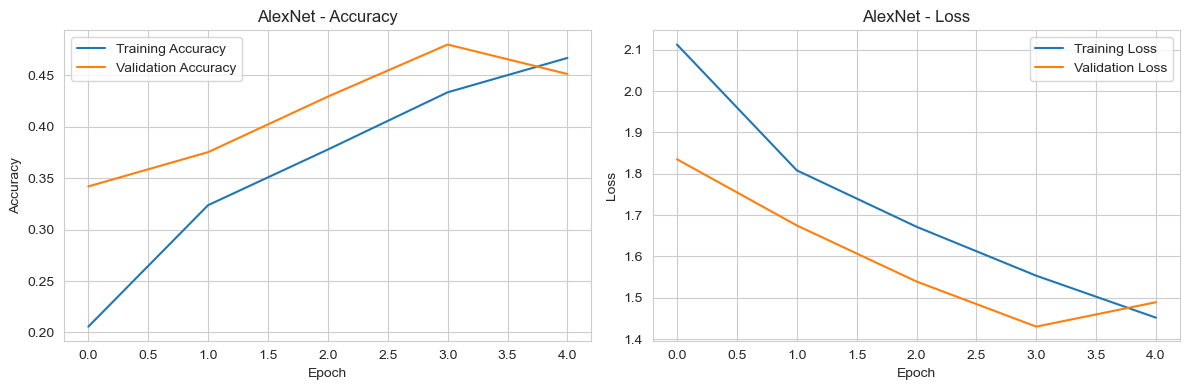

In [49]:
alexnet_history, alexnet_time = train_model(alexnet_model, alexnet_train_ds, alexnet_val_ds,
                                             model_name="alexnet", epochs=EPOCHS)
plot_history(alexnet_history, "AlexNet")


## AlexNet Evaluation


=== AlexNet Evaluation ===
Test Loss     : 1.4180
Test Accuracy : 0.4835
Precision     : 0.4786
Recall        : 0.4835
F1-score      : 0.4651
Training time : 212.8 s
Total params  : 2,547,722
Trainable params: 2,547,722


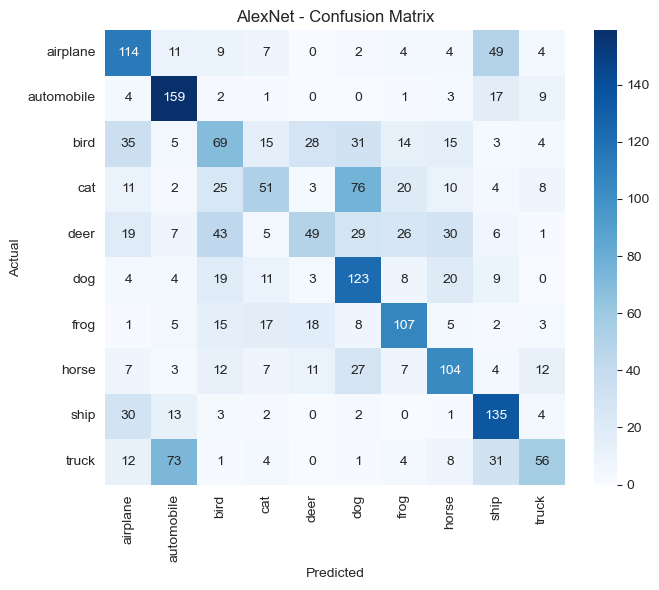


Classification Report:
              precision    recall  f1-score   support

    airplane       0.48      0.56      0.52       204
  automobile       0.56      0.81      0.67       196
        bird       0.35      0.32      0.33       219
         cat       0.42      0.24      0.31       210
        deer       0.44      0.23      0.30       215
         dog       0.41      0.61      0.49       201
        frog       0.56      0.59      0.58       181
       horse       0.52      0.54      0.53       194
        ship       0.52      0.71      0.60       190
       truck       0.55      0.29      0.38       190

    accuracy                           0.48      2000
   macro avg       0.48      0.49      0.47      2000
weighted avg       0.48      0.48      0.47      2000



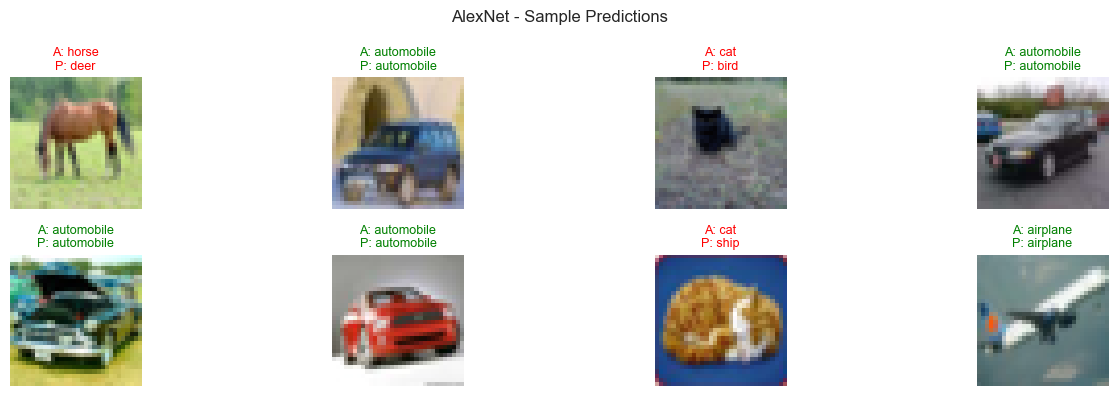

AlexNet model saved.


In [50]:
alexnet_result, alexnet_y_pred = evaluate_model(
    alexnet_model, alexnet_test_ds, y_test,
    model_name="AlexNet", elapsed_time=alexnet_time,
    pretrained=False, fine_tuned=False,
)
results_list.append(alexnet_result)

show_sample_predictions(x_test, y_test, alexnet_y_pred, "AlexNet")

# Save the final model explicitly (ModelCheckpoint already saved the best epoch)
alexnet_model.save(os.path.join(MODELS_DIR, "alexnet_cifar10.keras"))
print("AlexNet model saved.")


In [22]:
# Memory cleanup after AlexNet -- required before moving to the next model.
cleanup(alexnet_model, alexnet_train_ds, alexnet_val_ds, alexnet_test_ds)



Memory cleaned up (Keras session cleared, garbage collected).


## Generic Transfer-Learning Model Builder

VGG16, ResNet50, and EfficientNetB0 all follow the same transfer-learning pattern, so one shared function builds all three: load the ImageNet-pretrained convolutional base with `include_top=False`, freeze it, and attach a small new classification head.


In [26]:
def build_transfer_model(base_model_fn, img_size, num_classes=NUM_CLASSES,
                          base_trainable=False, dense_units=256, dropout=0.4,
                          learning_rate=LEARNING_RATE):
    """
    base_model_fn: e.g. tf.keras.applications.VGG16
    Builds: pretrained_base -> GlobalAveragePooling2D -> Dense -> Dropout -> Dense(softmax)
    """
    base_model = base_model_fn(weights="imagenet", include_top=False,
                                input_shape=(*img_size, 3))
    base_model.trainable = base_trainable  # freeze pretrained convolutional base initially

    inputs = tf.keras.Input(shape=(*img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model

print("Generic transfer-learning builder defined.")


Generic transfer-learning builder defined.


## VGG16 Implementation

Uses the official `tf.keras.applications.VGG16` with `weights="imagenet"`, convolutional base frozen initially (feature extraction). A new classification head is added for CIFAR-10's 10 classes.

```text
VGG16 convolutional base (frozen)
        |
GlobalAveragePooling2D
        |
Dense(256, relu)
        |
Dropout(0.4)
        |
Dense(10, softmax)
```


In [27]:
vgg16_model, vgg16_base = build_transfer_model(
    tf.keras.applications.VGG16, img_size=IMG_SIZE_PRETRAINED, base_trainable=False
)
vgg16_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
vgg16_preprocess = make_preprocess_fn("vgg16")

vgg16_train_ds = build_dataset(x_train, y_train, IMG_SIZE_PRETRAINED, vgg16_preprocess,
                                BATCH_SIZE, shuffle=True, augment=True)
vgg16_val_ds = build_dataset(x_val, y_val, IMG_SIZE_PRETRAINED, vgg16_preprocess,
                              BATCH_SIZE, shuffle=False, augment=False)
vgg16_test_ds = build_dataset(x_test, y_test, IMG_SIZE_PRETRAINED, vgg16_preprocess,
                               BATCH_SIZE, shuffle=False, augment=False)

print("VGG16 datasets ready.")


VGG16 datasets ready.


## VGG16 Training



--- Training vgg16 ---
Epoch 1/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1599s 1s/step - accuracy: 0.4625 - loss: 1.8249 - val_accuracy: 0.7220 - val_loss: 0.8505 - learning_rate: 1.0000e-04
Epoch 2/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 733s 689ms/step - accuracy: 0.6725 - loss: 0.9533 - val_accuracy: 0.7693 - val_loss: 0.6817 - learning_rate: 1.0000e-04
Epoch 3/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 735s 692ms/step - accuracy: 0.7382 - loss: 0.7733 - val_accuracy: 0.7933 - val_loss: 0.6251 - learning_rate: 1.0000e-04
Epoch 4/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 735s 691ms/step - accuracy: 0.7746 - loss: 0.6645 - val_accuracy: 0.8127 - val_loss: 0.5573 - learning_rate: 1.0000e-04
Epoch 5/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 737s 694ms/step - accuracy: 0.7971 - loss: 0.5989 - val_accuracy: 0.8227 - val_loss: 0.5279 - learning_rate: 1.0000e-04
--- Finished training vgg16 in 4539.7 seconds ---


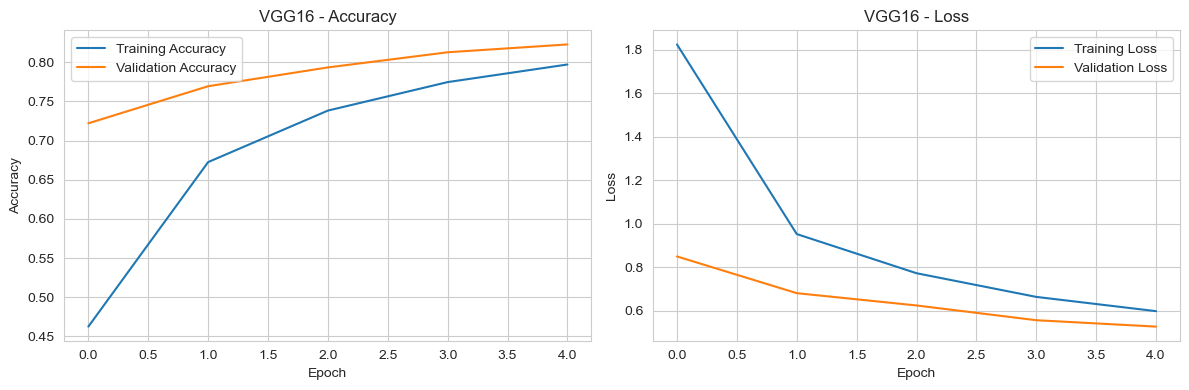

In [29]:
vgg16_history, vgg16_time = train_model(vgg16_model, vgg16_train_ds, vgg16_val_ds,
                                         model_name="vgg16", epochs=EPOCHS)
plot_history(vgg16_history, "VGG16")

##  VGG16 Evaluation


=== VGG16 Evaluation ===
Test Loss     : 0.5591
Test Accuracy : 0.8030
Precision     : 0.8055
Recall        : 0.8030
F1-score      : 0.8018
Training time : 4539.7 s
Total params  : 14,848,586
Trainable params: 133,898


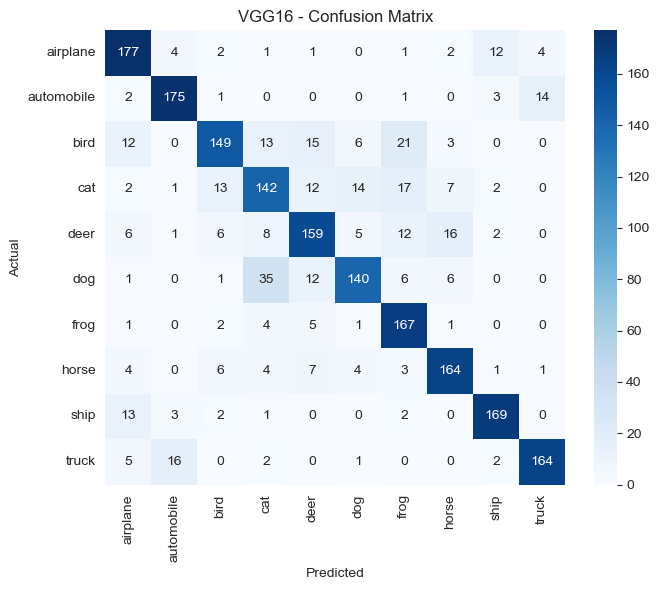


Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.87      0.83       204
  automobile       0.88      0.89      0.88       196
        bird       0.82      0.68      0.74       219
         cat       0.68      0.68      0.68       210
        deer       0.75      0.74      0.75       215
         dog       0.82      0.70      0.75       201
        frog       0.73      0.92      0.81       181
       horse       0.82      0.85      0.83       194
        ship       0.88      0.89      0.89       190
       truck       0.90      0.86      0.88       190

    accuracy                           0.80      2000
   macro avg       0.81      0.81      0.80      2000
weighted avg       0.81      0.80      0.80      2000



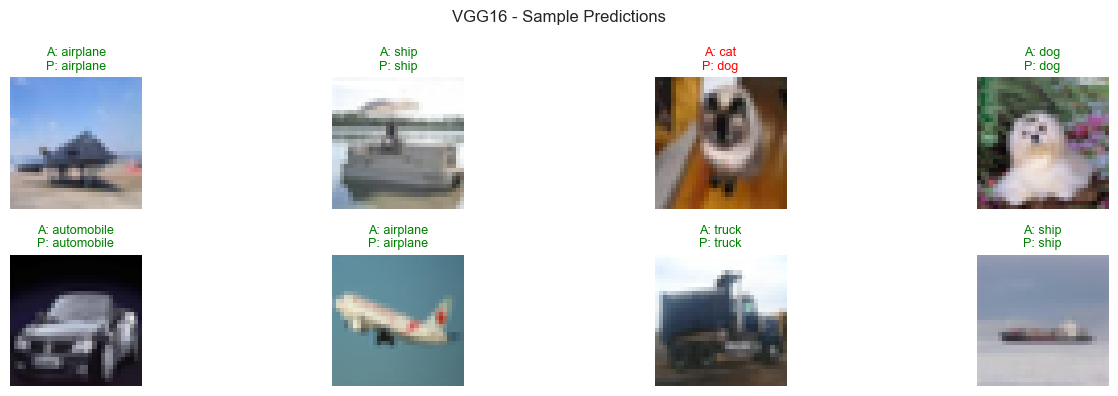

VGG16 model saved.


In [44]:
vgg16_result, vgg16_y_pred = evaluate_model(
    vgg16_model, vgg16_test_ds, y_test,
    model_name="VGG16", elapsed_time=vgg16_time,
    pretrained=True, fine_tuned=False,
)
results_list.append(vgg16_result)

show_sample_predictions(x_test, y_test, vgg16_y_pred, "VGG16")

vgg16_model.save(os.path.join(MODELS_DIR, "vgg16_cifar10.keras"))
print("VGG16 model saved.")


In [31]:
# Memory cleanup after VGG16 -- required before moving to the next model.
cleanup(vgg16_model, vgg16_base, vgg16_train_ds, vgg16_val_ds, vgg16_test_ds)



Memory cleaned up (Keras session cleared, garbage collected).


##  ResNet50 Implementation



In [32]:
resnet50_model, resnet50_base = build_transfer_model(
    tf.keras.applications.ResNet50, img_size=IMG_SIZE_PRETRAINED, base_trainable=False
)
resnet50_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [33]:
resnet50_preprocess = make_preprocess_fn("resnet50")

resnet50_train_ds = build_dataset(x_train, y_train, IMG_SIZE_PRETRAINED, resnet50_preprocess,
                                   BATCH_SIZE, shuffle=True, augment=True)
resnet50_val_ds = build_dataset(x_val, y_val, IMG_SIZE_PRETRAINED, resnet50_preprocess,
                                 BATCH_SIZE, shuffle=False, augment=False)
resnet50_test_ds = build_dataset(x_test, y_test, IMG_SIZE_PRETRAINED, resnet50_preprocess,
                                  BATCH_SIZE, shuffle=False, augment=False)

print("ResNet50 datasets ready.")


ResNet50 datasets ready.


## ResNet50 Training

--- Training resnet50 ---
Epoch 1/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 426s 395ms/step - accuracy: 0.7112 - loss: 0.8663 - val_accuracy: 0.8700 - val_loss: 0.4039 - learning_rate: 1.0000e-04
Epoch 2/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 421s 396ms/step - accuracy: 0.8521 - loss: 0.4391 - val_accuracy: 0.8820 - val_loss: 0.3600 - learning_rate: 1.0000e-04
Epoch 3/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 423s 398ms/step - accuracy: 0.8739 - loss: 0.3633 - val_accuracy: 0.8893 - val_loss: 0.3415 - learning_rate: 1.0000e-04
Epoch 4/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 427s 402ms/step - accuracy: 0.8968 - loss: 0.2983 - val_accuracy: 0.8980 - val_loss: 0.3026 - learning_rate: 1.0000e-04
Epoch 5/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 419s 394ms/step - accuracy: 0.9111 - loss: 0.2555 - val_accuracy: 0.8893 - val_loss: 0.3078 - learning_rate: 1.0000e-04
--- Finished training resnet50 in 2115.8 seconds ---


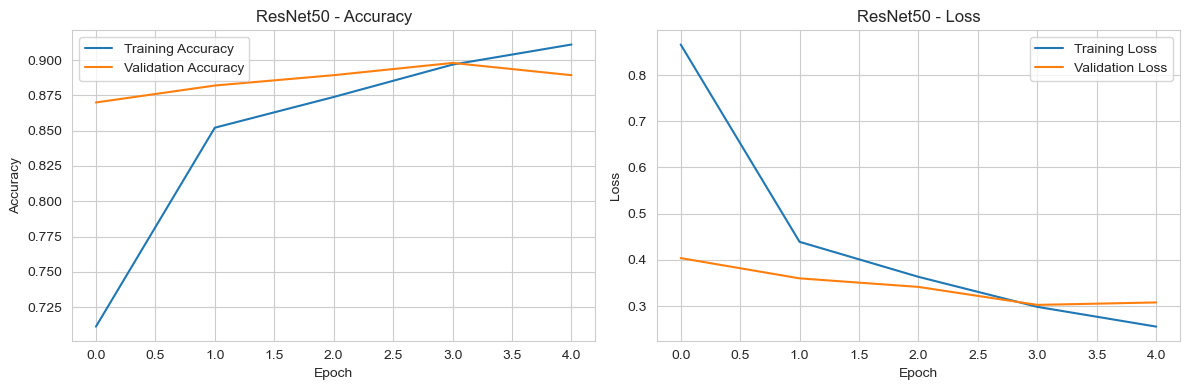

In [34]:
resnet50_history, resnet50_time = train_model(resnet50_model, resnet50_train_ds, resnet50_val_ds,
                                               model_name="resnet50", epochs=EPOCHS)
plot_history(resnet50_history, "ResNet50")


## ResNet50 Evaluation


=== ResNet50 Evaluation ===
Test Loss     : 0.3142
Test Accuracy : 0.8985
Precision     : 0.8989
Recall        : 0.8985
F1-score      : 0.8984
Training time : 2115.8 s
Total params  : 24,114,826
Trainable params: 527,114


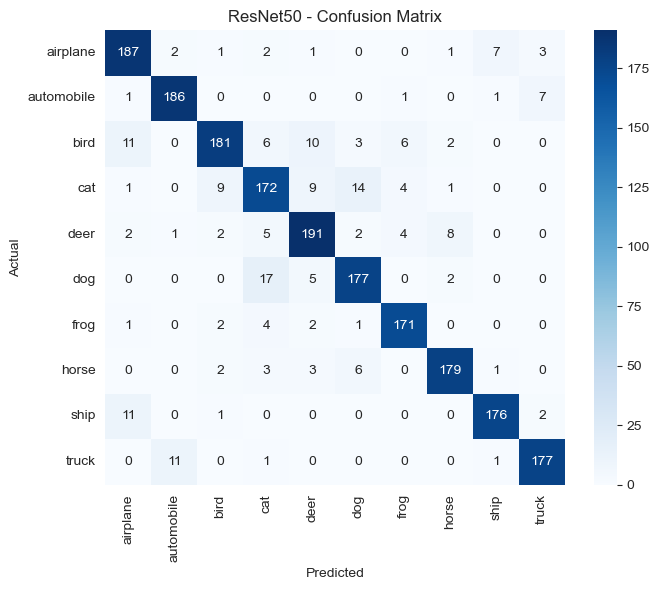


Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.92      0.89       204
  automobile       0.93      0.95      0.94       196
        bird       0.91      0.83      0.87       219
         cat       0.82      0.82      0.82       210
        deer       0.86      0.89      0.88       215
         dog       0.87      0.88      0.88       201
        frog       0.92      0.94      0.93       181
       horse       0.93      0.92      0.93       194
        ship       0.95      0.93      0.94       190
       truck       0.94      0.93      0.93       190

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



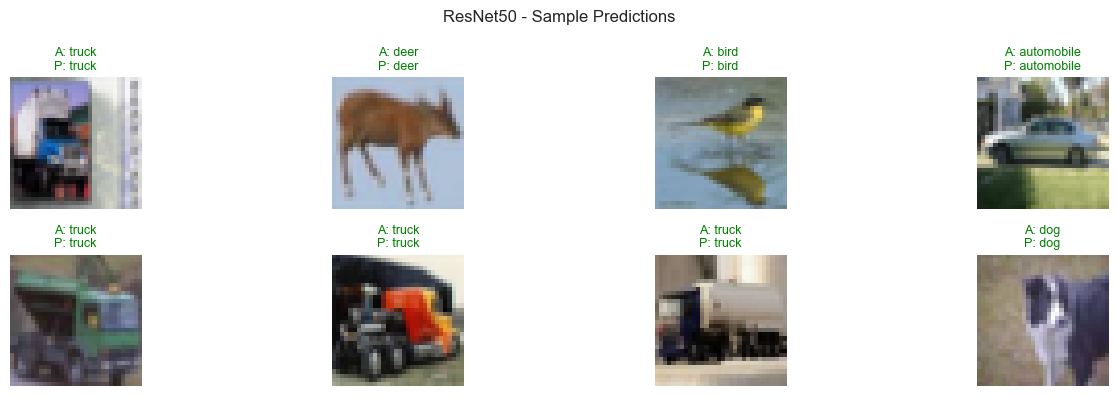

ResNet50 model saved.


In [43]:
resnet50_result, resnet50_y_pred = evaluate_model(
    resnet50_model, resnet50_test_ds, y_test,
    model_name="ResNet50", elapsed_time=resnet50_time,
    pretrained=True, fine_tuned=False,
)
results_list.append(resnet50_result)

show_sample_predictions(x_test, y_test, resnet50_y_pred, "ResNet50")

resnet50_model.save(os.path.join(MODELS_DIR, "resnet50_cifar10.keras"))
print("ResNet50 model saved.")


In [36]:
# Memory cleanup after ResNet50 -- required before moving to the next model.
cleanup(resnet50_model, resnet50_base, resnet50_train_ds, resnet50_val_ds, resnet50_test_ds)


Memory cleaned up (Keras session cleared, garbage collected).


## EfficientNetB0 Implementation



In [37]:
efficientnet_model, efficientnet_base = build_transfer_model(
    tf.keras.applications.EfficientNetB0, img_size=IMG_SIZE_PRETRAINED, base_trainable=False
)
efficientnet_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [38]:
efficientnet_preprocess = make_preprocess_fn("efficientnetb0")

efficientnet_train_ds = build_dataset(x_train, y_train, IMG_SIZE_PRETRAINED, efficientnet_preprocess,
                                       BATCH_SIZE, shuffle=True, augment=True)
efficientnet_val_ds = build_dataset(x_val, y_val, IMG_SIZE_PRETRAINED, efficientnet_preprocess,
                                     BATCH_SIZE, shuffle=False, augment=False)
efficientnet_test_ds = build_dataset(x_test, y_test, IMG_SIZE_PRETRAINED, efficientnet_preprocess,
                                      BATCH_SIZE, shuffle=False, augment=False)

print("EfficientNetB0 datasets ready.")


EfficientNetB0 datasets ready.


## EfficientNetB0 Training

--- Training efficientnetb0 ---
Epoch 1/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 206s 186ms/step - accuracy: 0.7279 - loss: 0.9038 - val_accuracy: 0.8507 - val_loss: 0.4685 - learning_rate: 1.0000e-04
Epoch 2/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 202s 190ms/step - accuracy: 0.8394 - loss: 0.4823 - val_accuracy: 0.8693 - val_loss: 0.3954 - learning_rate: 1.0000e-04
Epoch 3/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 202s 190ms/step - accuracy: 0.8651 - loss: 0.4132 - val_accuracy: 0.8813 - val_loss: 0.3727 - learning_rate: 1.0000e-04
Epoch 4/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 207s 195ms/step - accuracy: 0.8793 - loss: 0.3616 - val_accuracy: 0.8847 - val_loss: 0.3479 - learning_rate: 1.0000e-04
Epoch 5/5
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 203s 191ms/step - accuracy: 0.8805 - loss: 0.3415 - val_accuracy: 0.8847 - val_loss: 0.3469 - learning_rate: 1.0000e-04
--- Finished training efficientnetb0 in 1020.3 seconds ---


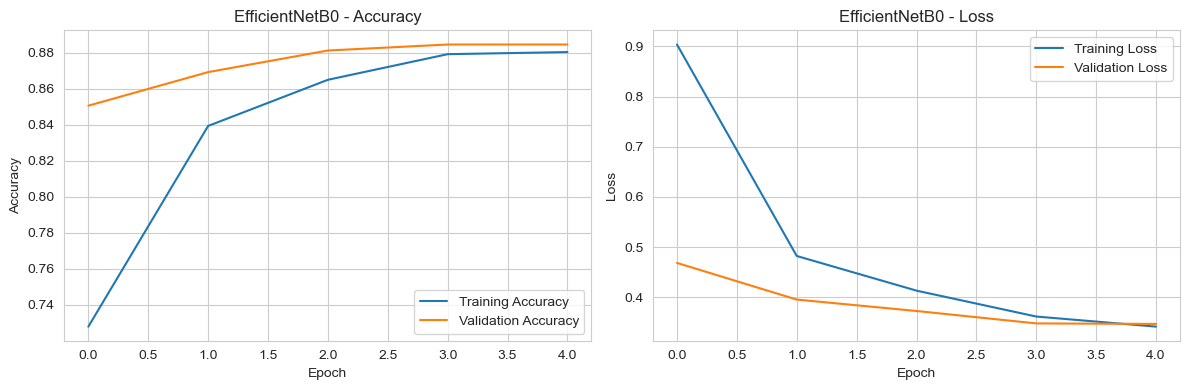

In [39]:
efficientnet_history, efficientnet_time = train_model(
    efficientnet_model, efficientnet_train_ds, efficientnet_val_ds,
    model_name="efficientnetb0", epochs=EPOCHS,
)
plot_history(efficientnet_history, "EfficientNetB0")


## EfficientNetB0 Evaluation


=== EfficientNetB0 Evaluation ===
Test Loss     : 0.3419
Test Accuracy : 0.8860
Precision     : 0.8867
Recall        : 0.8860
F1-score      : 0.8854
Training time : 1020.3 s
Total params  : 4,380,077
Trainable params: 330,506


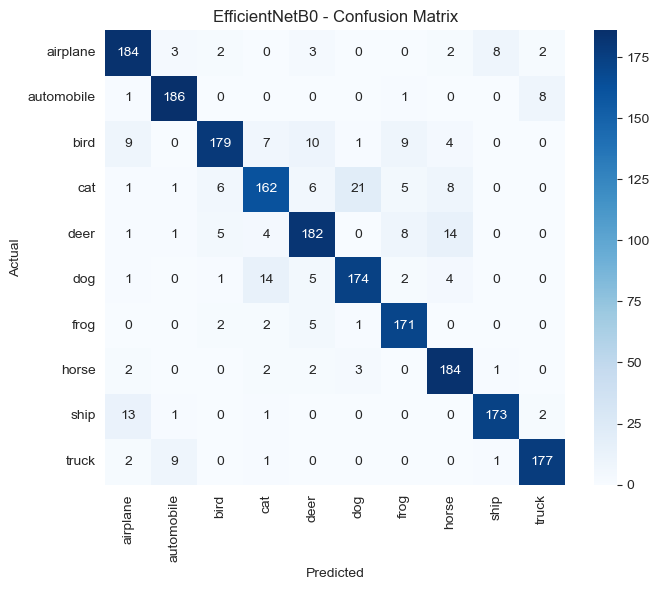


Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.90      0.88       204
  automobile       0.93      0.95      0.94       196
        bird       0.92      0.82      0.86       219
         cat       0.84      0.77      0.80       210
        deer       0.85      0.85      0.85       215
         dog       0.87      0.87      0.87       201
        frog       0.87      0.94      0.91       181
       horse       0.85      0.95      0.90       194
        ship       0.95      0.91      0.93       190
       truck       0.94      0.93      0.93       190

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



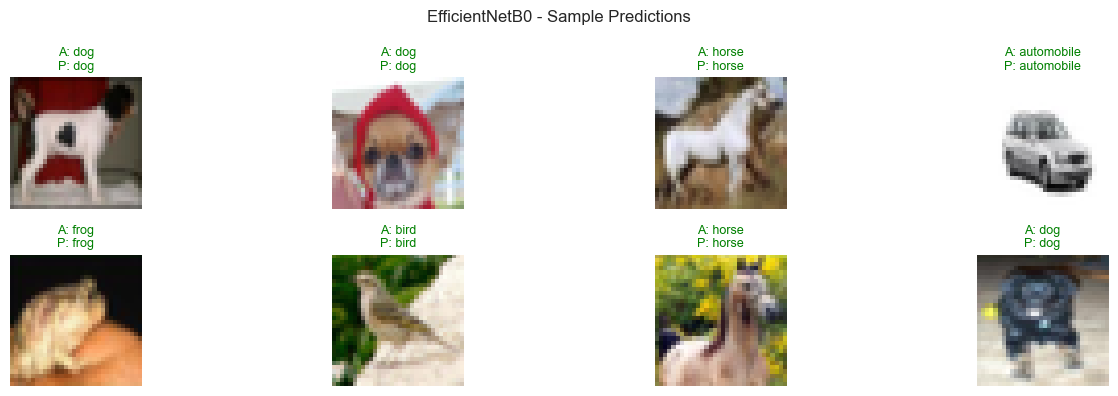

EfficientNetB0 model saved.


In [40]:
efficientnet_result, efficientnet_y_pred = evaluate_model(
    efficientnet_model, efficientnet_test_ds, y_test,
    model_name="EfficientNetB0", elapsed_time=efficientnet_time,
    pretrained=True, fine_tuned=False,
)
results_list.append(efficientnet_result)

show_sample_predictions(x_test, y_test, efficientnet_y_pred, "EfficientNetB0")

efficientnet_model.save(os.path.join(MODELS_DIR, "efficientnetb0_cifar10.keras"))
print("EfficientNetB0 model saved.")


In [41]:
# Memory cleanup after EfficientNetB0.
cleanup(efficientnet_model, efficientnet_base, efficientnet_train_ds, efficientnet_val_ds, efficientnet_test_ds)


Memory cleaned up (Keras session cleared, garbage collected).


##  Model Comparison


In [51]:
comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df[[
    "Model", "Test Accuracy", "Precision", "Recall", "F1 Score",
    "Training Time (s)", "Total Parameters", "Trainable Parameters",
    "Train Samples", "Test Samples", "Epochs",
    "Pretrained (ImageNet)", "Fine-tuned",
]]
comparison_df


,Model,Test Accuracy,Precision,Recall,F1 Score,Training Time (s),Total Parameters,Trainable Parameters,Train Samples,Test Samples,Epochs,Pretrained (ImageNet),Fine-tuned
0,EfficientNetB0,0.8860,0.8867,0.8860,0.8854,1020.3,4380077,330506,8500,2000,5,True,False
1,ResNet50,0.8985,0.8989,0.8985,0.8984,2115.8,24114826,527114,8500,2000,5,True,False
2,VGG16,0.8030,0.8055,0.8030,0.8018,4539.7,14848586,133898,8500,2000,5,True,False
3,AlexNet,0.4835,0.4786,0.4835,0.4651,212.8,2547722,2547722,8500,2000,5,False,False


## Final Results Table

Saved to `model_comparison.csv` for submission alongside this notebook.


In [52]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Saved model_comparison.csv")
comparison_df


Saved model_comparison.csv


,Model,Test Accuracy,Precision,Recall,F1 Score,Training Time (s),Total Parameters,Trainable Parameters,Train Samples,Test Samples,Epochs,Pretrained (ImageNet),Fine-tuned
0,EfficientNetB0,0.8860,0.8867,0.8860,0.8854,1020.3,4380077,330506,8500,2000,5,True,False
1,ResNet50,0.8985,0.8989,0.8985,0.8984,2115.8,24114826,527114,8500,2000,5,True,False
2,VGG16,0.8030,0.8055,0.8030,0.8018,4539.7,14848586,133898,8500,2000,5,True,False
3,AlexNet,0.4835,0.4786,0.4835,0.4651,212.8,2547722,2547722,8500,2000,5,False,False


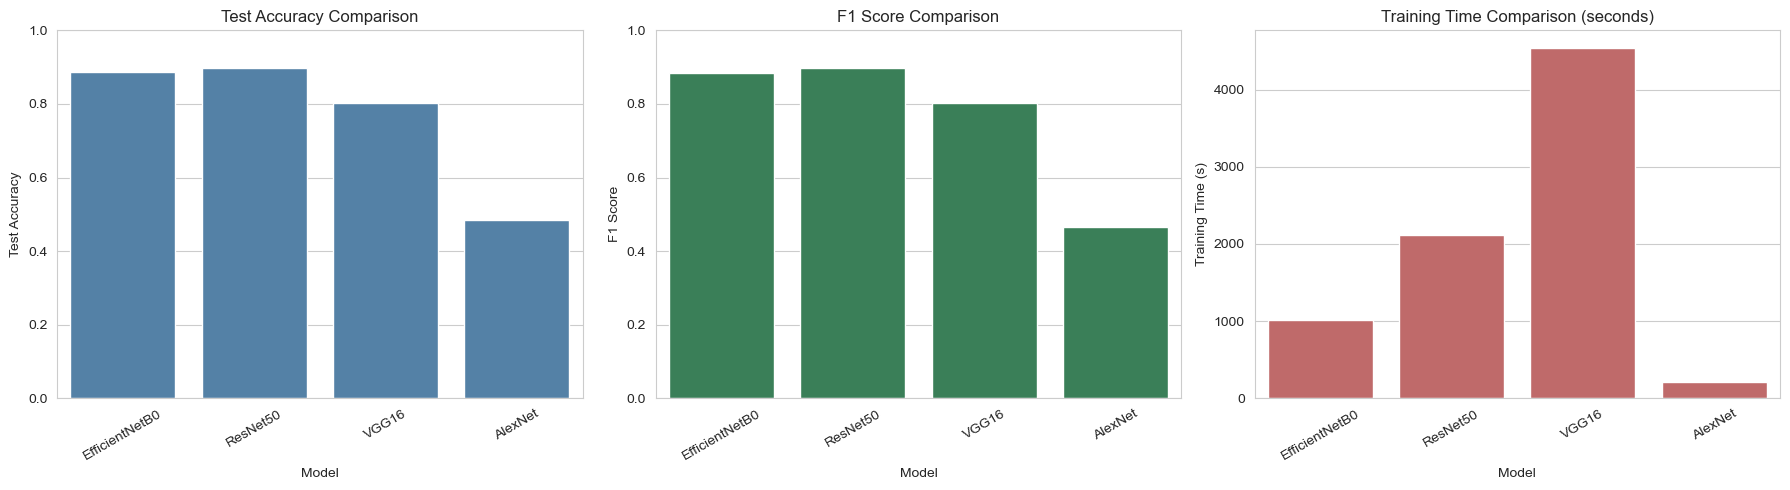

In [53]:
# Comparison visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=comparison_df, x="Model", y="Test Accuracy", ax=axes[0], color="steelblue")
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison_df, x="Model", y="F1 Score", ax=axes[1], color="seagreen")
axes[1].set_title("F1 Score Comparison")
axes[1].set_ylim(0, 1)

sns.barplot(data=comparison_df, x="Model", y="Training Time (s)", ax=axes[2], color="indianred")
axes[2].set_title("Training Time Comparison (seconds)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("model_comparison_charts.png", dpi=150)
plt.show()


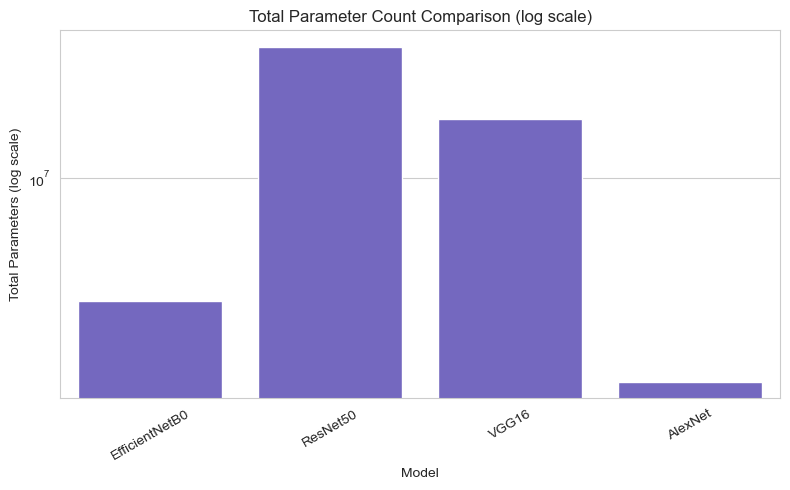

In [54]:
# Parameter count comparison (log scale, since pretrained models have far more params than AlexNet-style CNN)
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Total Parameters", color="slateblue")
plt.yscale("log")
plt.title("Total Parameter Count Comparison (log scale)")
plt.ylabel("Total Parameters (log scale)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
